### __- Importation des librairies__

In [1]:
import os
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

<br>

### __*- Prétraitement des données pour le COVID-19 X-ray dataset*__   
* __Uniformiser toutes les images à la même taille (224 x 224).__

* __Normaliser les pixels entre 0 et 1.__

* __Diviser les données : ( 70% → Entraînement,  15% → Validation,  15% → Test)__

<br>
<hr>

##### __*Dataset*__: 
* __*COVID-19 Radiography Database  :*__ https://www.kaggle.com/datasets/amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset
* ( J'ai supprimer le pneumonia car mon projet se concentre sur la détection du COVID-19 uniquement )

<br>
<hr>

In [2]:


# Configuration
config = {
    "DATA_DIR": "data/covid19",
    "IMG_SIZE": 224, 
    "BATCH_SIZE": 32,
    "EPOCHS": 10,
    "LEARNING_RATE": 0.0001,
    "SEED": 42,
    "USE_AUGMENTATION": True,
    "MODEL_SAVE_PATH": "models/covid19_xray_model_v4.h5"
}


# Extraire les paramètres
DATA_DIR = config["DATA_DIR"]
IMG_SIZE = config["IMG_SIZE"]
BATCH_SIZE = config["BATCH_SIZE"]
EPOCHS = config["EPOCHS"]
LEARNING_RATE = config["LEARNING_RATE"]
SEED = config["SEED"]
MODEL_SAVE_PATH = config["MODEL_SAVE_PATH"]



def image_padding(image, label):
    """
    Transforme l'image en carré centré par padding noir, puis la redimensionne

    Args:
        image: Tensor (H, W, C) avec pixels en [0, 255]
        label: Label associé

    Returns:
        (image_transformée, label) : image normalisée, carrée et taille IMG_SIZE
    """
    # Normalisation
    image = tf.cast(image, tf.float32) / 255.0

    height = tf.shape(image)[0]
    width = tf.shape(image)[1]
    max_dim = tf.maximum(height, width)

    # Calcul padding
    pad_h = max_dim - height
    pad_w = max_dim - width

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    # Padding explicite
    image = tf.pad(
        image,
        paddings=[
            [pad_top, pad_bottom],    # Padding vertical
            [pad_left, pad_right],    # Padding horizontal
            [0, 0]                    # Pas de padding canaux couleur
        ],
        mode='CONSTANT',
        constant_values=0.0
    )

    # Redimensionnement
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    return image, label






train_data_complet = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode='binary',
    class_names=['normal', 'covid'],
    seed=SEED,
    shuffle=True,
    batch_size=None
)


# image preprocessing avec padding
train_data_complet = train_data_complet.map(
    image_padding,
    num_parallel_calls=tf.data.AUTOTUNE
)


Found 4589 files belonging to 2 classes.


In [3]:
original_heights = []
original_widths = []

for ext in ('*.png', '*.jpg', '*.jpeg'):
    for file_path in Path(DATA_DIR).rglob(ext):
        img = tf.keras.preprocessing.image.load_img(file_path)
        original_heights.append(img.size[1])
        original_widths.append(img.size[0])

print("Hauteur originale des images : ", np.min(original_heights), " - ", np.max(original_heights))
print("Largeur originale des images  : ", np.min(original_widths), " - ", np.max(original_widths))

Hauteur originale des images :  206  -  4757
Largeur originale des images  :  205  -  5623


In [4]:
print("\n=== Avec padding et sans padding ===\n")

# Distorsion sans padding
distortion_resize = []
for w, h in zip(original_widths, original_heights):
    original_ratio = w / h
    distortion_resize.append(abs(original_ratio - 1.0))

# Distorsion réelle avec padding
distortion_padding = [0] * len(original_widths)



print(f"SANS padding (resize direct):")
print(f"  Distorsion moyenne: {np.mean(distortion_resize):.3f}")

print(f"\nAVEC padding (votre méthode):")
print(f"  Distorsion moyenne: {np.mean(distortion_padding):.3f}")


=== Avec padding et sans padding ===

SANS padding (resize direct):
  Distorsion moyenne: 0.053

AVEC padding (votre méthode):
  Distorsion moyenne: 0.000


<br>
<br>


### __*2. Vérification de la  normaliser les pixels entre 0 et 1*__

In [5]:
# Vérification des valeurs des pixels après normalisation
for images, labels in train_data_complet.take(1):
    img = images[0].numpy()
    print("Valeurs min de l'image en pixels :", img.min())
    print("Valeurs max de l'image en pixels :", img.max())
    print("Type de données (dtype)        :", img.dtype)

Valeurs min de l'image en pixels : 0.0
Valeurs max de l'image en pixels : 0.0
Type de données (dtype)        : float32


<br>
<br>

### __*3. Conversion en arrays numpy*__

In [6]:

X_list, y_list = [], []
for images, labels in train_data_complet:
    X_list.append(images.numpy())
    y_list.append(labels.numpy())

X = np.array(X_list)
y = np.array(y_list).flatten()
print(f"Total images: {len(X)}")

Total images: 4589


<br>
<br>

### __*4. Diviser les données train / validation / test*__

In [7]:
from sklearn.model_selection import train_test_split



# Split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Split: Diviser temp en 50/50 = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 3212 | Val: 688 | Test: 689


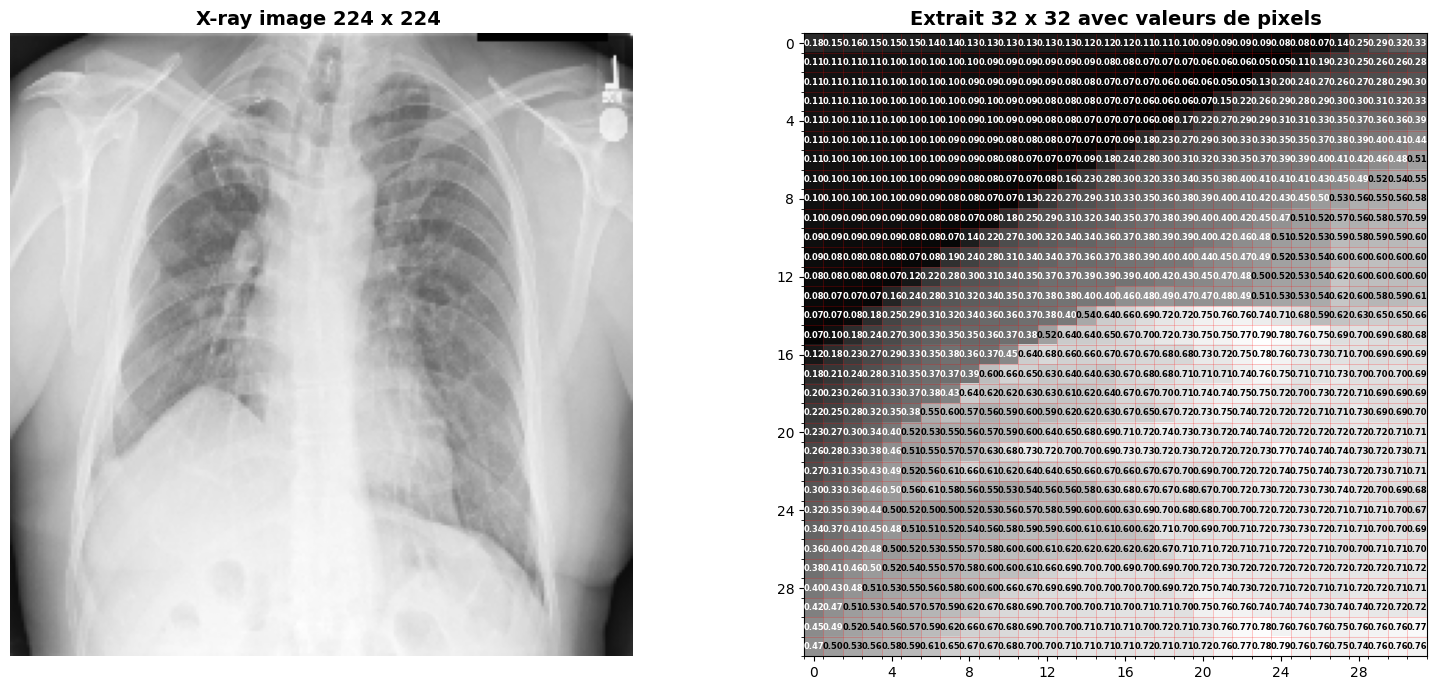

In [8]:
import matplotlib.pyplot as plt
import numpy as np





img = X_train[0]
gray = np.mean(img, axis=-1)

excerpt = gray[:32, :32]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.imshow(gray, cmap='gray')
ax1.set_title("X-ray image 224 x 224 ", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.imshow(excerpt, cmap='gray', interpolation='nearest')
ax2.set_title("Extrait 32 x 32 avec valeurs de pixels", fontsize=14, fontweight='bold')


# Afficher les valeurs numériques de chaque pixel
for i in range(32):
    for j in range(32):
        pixel_value = excerpt[i, j]
        text_color = 'white' if pixel_value < 0.5 else 'black'
        ax2.text(j, i, f"{pixel_value:.2f}",
                ha="center", va="center",
                color=text_color, fontsize=6, fontweight='bold')

# lignes de grille
ax2.set_xticks(np.arange(-0.5, 32, 1), minor=True)
ax2.set_yticks(np.arange(-0.5, 32, 1), minor=True)
ax2.grid(which='minor', color='red', linestyle='-', linewidth=0.5, alpha=0.3)
ax2.set_xticks(np.arange(0, 32, 4))
ax2.set_yticks(np.arange(0, 32, 4))



plt.tight_layout()
plt.show()

Affichage d'un batch de 32 images


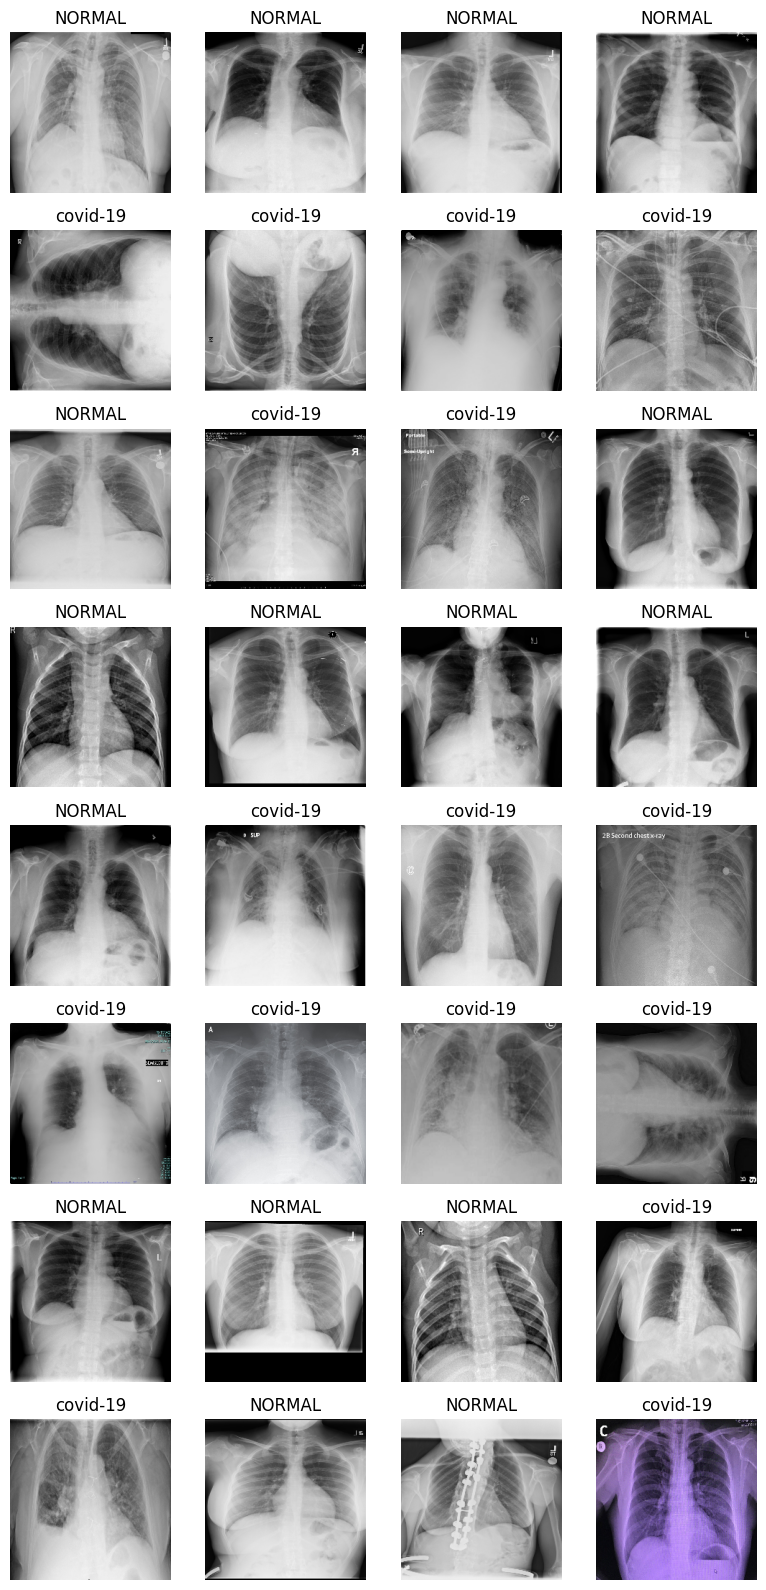

In [9]:
# Les notes :
# index 0 : NORMAL
# index 1 : COVID-19


# Prendre un seul batch

batch_size = min(32, len(X_train))
images = X_train[:batch_size]
labels = y_train[:batch_size]

print(f"Affichage d'un batch de {batch_size} images")

# Calculer le nombre de lignes et colonnes pour la grille
cols = min(4, batch_size)
rows = math.ceil(batch_size / cols)

plt.figure(figsize=(cols * 2, rows * 2))

for i in range(batch_size):
    img = images[i]

    if img.min() < 0:
        img = (img + 1) / 2
    elif img.max() > 1.0:
        img = img / 255.0

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title("NORMAL" if labels[i] == 0 else "covid-19")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)


<br>
<br>

#### __*- 5. Vérification des déséquilibres des classes avant de l'entraînement*__

In [11]:
# Référances :
      # https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

from sklearn.utils.class_weight import compute_class_weight




# Vérifiction de déséquilibre des classes global
unique_global, counts_global = np.unique(y, return_counts=True)
print("Distribution des classes dans l'ensemble de données complet:")
for label, count in zip(unique_global, counts_global):
    label_name = "normal" if label == 0 else "covid"
    percentage = (count / len(y)) * 100
    print(f"  {label_name}: {count:4d} images ({percentage:5.1f}%)")


# Vérification des déséquilibres sur train dataset
print("\n")
print("Distribution des classes dans l'ensemble d'entraînement:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    label_name = "normal" if label == 0 else "covid"
    percentage = (count / len(y_train)) * 100
    print(f"  {label_name}: {count:4d} images ({percentage:5.1f}%)")


# Vérification des déséquilibres sur val dataset
print("\n")
unique_val, counts_val = np.unique(y_val, return_counts=True)
for label, count in zip(unique_val, counts_val):
    label_name = "normal" if label == 0 else "covid"
    percentage = (count / len(y_val)) * 100
    print(f"  {label_name}: {count:4d} images ({percentage:5.1f}%)")


# Vérification des déséquilibres sur test dataset
print("\n")
print("Distribution des classes dans l'ensemble de test:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    label_name = "normal" if label == 0 else "covid"
    percentage = (count / len(y_test)) * 100
    print(f"  {label_name}: {count:4d} images ({percentage:5.1f}%)")


# Calculer les poids
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("\nPoids des classes pour l'entraînement:")
print(f"  normal (0):   {class_weight_dict[0]:.3f}")
print(f"  covid (1): {class_weight_dict[1]:.3f}")

Distribution des classes dans l'ensemble de données complet:
  normal: 2313 images ( 50.4%)
  covid: 2276 images ( 49.6%)


Distribution des classes dans l'ensemble d'entraînement:
  normal: 1619 images ( 50.4%)
  covid: 1593 images ( 49.6%)


  normal:  347 images ( 50.4%)
  covid:  341 images ( 49.6%)


Distribution des classes dans l'ensemble de test:
  normal:  347 images ( 50.4%)
  covid:  342 images ( 49.6%)

Poids des classes pour l'entraînement:
  normal (0):   0.992
  covid (1): 1.008


<br>
<br>


### __- 6. Construction du modèle CNN__

In [12]:
# Référence pour le modèle CNN
    # https://www.youtube.com/watch?v=jDe5BAsT2-Y
    # https://medium.com/@myringoleMLGOD/simple-convolutional-neural-network-cnn-for-dummies-in-pytorch-a-step-by-step-guide-6f4109f6df80
    # https://victorzhou.com/blog/intro-to-cnns-part-1/
    # https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175

# Padding images cnn
    # https://learnopencv.com/understanding-convolutional-neural-networks-cnn/
    # https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175



import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input




def covid_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=1):
    model = Sequential([
        Input(shape=input_shape),

        # Bloc Conv 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Bloc Conv 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Bloc Conv 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),


        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='sigmoid')
            # sigmoid car c'est une classification binaire
    ])
    return model


In [13]:
# Référence  (ADAM)
    # https://en.wikipedia.org/wiki/Stochastic_gradient_descent
    # https://datasciencewiki.net/adam-optimisation/


model = covid_cnn_model()

# Compilation avec Adam et binary crossentropy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

<br>
<br>

* `Pourquoi pas test pendant l'entraînement ?` Si le modèle voit les données de test pendant qu'il apprend, il va les mémoriser au lieu de généraliser. Le résultat final serait faux (gonflé artificiellement). 

In [14]:
# Entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


test_loss, test_acc = model.evaluate(test_ds, verbose=0)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 95s 769ms/step - accuracy: 0.7715 - loss: 0.5000 - val_accuracy: 0.8750 - val_loss: 0.2899
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 70s 685ms/step - accuracy: 0.8808 - loss: 0.2927 - val_accuracy: 0.9041 - val_loss: 0.2227
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 68s 678ms/step - accuracy: 0.9203 - loss: 0.2060 - val_accuracy: 0.9142 - val_loss: 0.1821
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 68s 670ms/step - accuracy: 0.9346 - loss: 0.1673 - val_accuracy: 0.9593 - val_loss: 0.1264
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 67s 660ms/step - accuracy: 0.9508 - loss: 0.1344 - val_accuracy: 0.9622 - val_loss: 0.1245
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 67s 662ms/step - accuracy: 0.9555 - loss: 0.1090 - val_accuracy: 0.9680 - val_loss: 0.1009
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 684ms/step - accuracy: 0.9701 - loss: 0.0758 - val_accuracy: 0.9695 - val_loss: 0.0963
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 67s 665ms/step - accuracy: 0.9757 - loss: 0

In [15]:

print("=== ÉVALUATION DU MODELE ===")

# Précision globale
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)

print(f"- Précision sur train set : {train_acc:.2%}")
print(f"- Précision sur validation set : {val_acc:.2%}")
print(f"- Précision sur le test set : {test_acc:.2%}")

# Rapport détaillé
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(((preds > 0.5).astype(int).flatten()).tolist())
    y_true.extend(labels.numpy().flatten().tolist())

print("\n- Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=['normal', 'covid']))

=== ÉVALUATION DU MODELE ===
- Précision sur train set : 99.72%
- Précision sur validation set : 97.24%
- Précision sur le test set : 97.39%

- Rapport de classification :
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97       347
       covid       0.98      0.97      0.97       342

    accuracy                           0.97       689
   macro avg       0.97      0.97      0.97       689
weighted avg       0.97      0.97      0.97       689



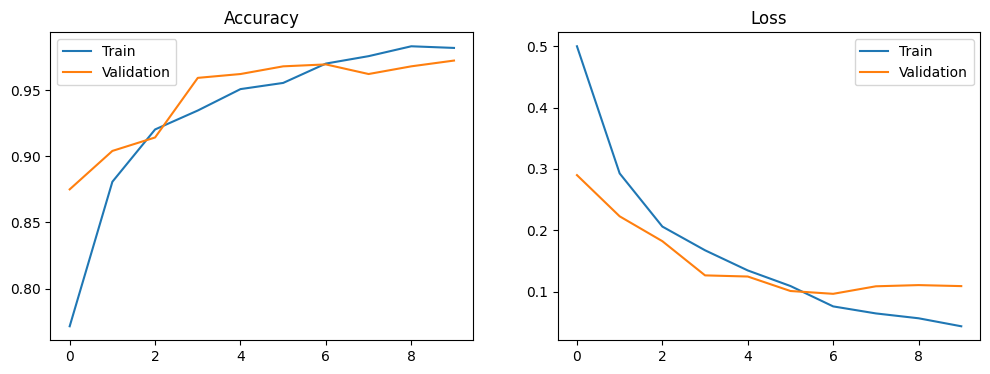

In [16]:
def plot_courbes(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss')
    ax2.legend()

    plt.show()

plot_courbes(history)

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step


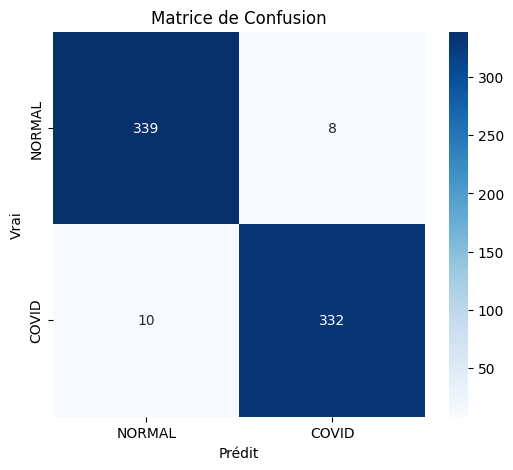

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns




def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'COVID'],
                yticklabels=['NORMAL', 'COVID'])
    plt.title('Matrice de Confusion')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.show()

# Prédictions
y_pred = (model.predict(test_ds) > 0.5).astype(int).flatten()
y_true = np.concatenate([y for _, y in test_ds]).flatten()

plot_confusion_matrix(y_true, y_pred)

<br>
<br>


### __- 7. Adam vs SGD__

In [18]:
import tensorflow as tf


def get_optimizers():
    return {
        'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
        'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    }



def train_sequential(train_ds, val_ds, test_ds, epochs):
    """Entraîne les modèles séquentiellement et retourne métriques + historiques"""
    results = {}
    histories = {}
    optimizers = get_optimizers()

    print(f"\nComparaison de {len(optimizers)} optimiseurs...")

    for i, (name, optimizer) in enumerate(optimizers.items(), 1):
        print(f"\n[{i}/{len(optimizers)}] Entraînement avec {name}...")

        model = covid_cnn_model()
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            verbose=1
        )

        # Sauvegarder l'objet history
        histories[name] = history

        # Évaluer sur test
        _, test_acc = model.evaluate(test_ds, verbose=0)

        results[name] = {
            'train': history.history['accuracy'][-1],
            'val': history.history['val_accuracy'][-1],
            'test': test_acc
        }

        del model
        tf.keras.backend.clear_session()
        print(f"{name} terminé - Test accuracy: {test_acc:.2%}")

    return results, histories



def print_results(results):
    print("\n" + "="*50)
    print("Résultats de performance par optimiseur")
    print("="*50)

    for name, m in sorted(results.items(), key=lambda x: x[1]['test'], reverse=True):
        print(f"{name:10s}: Train= {m['train']:.2%}, Val= {m['val']:.2%}, Test= {m['test']:.2%}")


# la comparaison
results, histories = train_sequential(train_ds, val_ds, test_ds, epochs=EPOCHS)
print_results(results)



Comparaison de 2 optimiseurs...

[1/2] Entraînement avec SGD...
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 64s 622ms/step - accuracy: 0.6790 - loss: 0.6007 - val_accuracy: 0.7456 - val_loss: 0.5256
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 63s 628ms/step - accuracy: 0.7625 - loss: 0.4976 - val_accuracy: 0.7980 - val_loss: 0.4170
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 63s 620ms/step - accuracy: 0.7970 - loss: 0.4445 - val_accuracy: 0.8096 - val_loss: 0.4053
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 62s 611ms/step - accuracy: 0.8257 - loss: 0.4082 - val_accuracy: 0.8387 - val_loss: 0.3771
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 62s 609ms/step - accuracy: 0.8381 - loss: 0.3797 - val_accuracy: 0.8488 - val_loss: 0.3366
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 64s 634ms/step - accuracy: 0.8593 - loss: 0.3532 - val_accuracy: 0.8634 - val_loss: 0.3197
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 65s 645ms/step - accuracy: 0.8711 - loss: 0.3307 - val_accuracy: 0.8808 - val_loss: 0.2868
Epoch 8/10
101/101

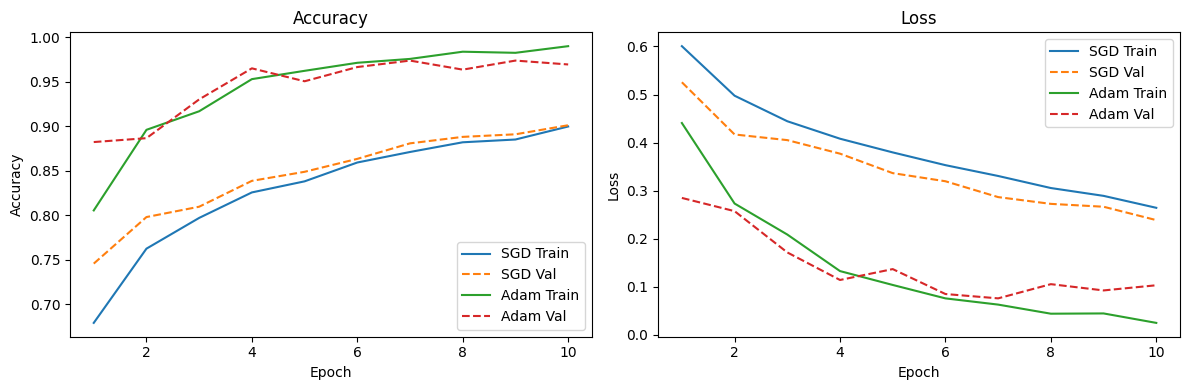

In [19]:
import matplotlib.pyplot as plt


def plot_optimizers_histories(histories):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    for name, h in histories.items():
        hist = h.history
        epochs_range = range(1, len(hist.get('loss', [])) + 1)

        # Accuracy
        acc = hist.get('accuracy') or hist.get('acc')
        val_acc = hist.get('val_accuracy') or hist.get('val_acc')
        if acc is not None:
            ax1.plot(epochs_range, acc, label=f'{name} Train')
        if val_acc is not None:
            ax1.plot(epochs_range, val_acc, linestyle='--', label=f'{name} Val')

        # Loss
        loss = hist.get('loss')
        val_loss = hist.get('val_loss')
        if loss is not None:
            ax2.plot(epochs_range, loss, label=f'{name} Train')
        if val_loss is not None:
            ax2.plot(epochs_range, val_loss, linestyle='--', label=f'{name} Val')

    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()


# Tracer les courbes pour Adam et SGD
plot_optimizers_histories(histories)


In [20]:
# Sauvegarder le modèle
model.save(MODEL_SAVE_PATH)
print(f"Modèle sauvegardé : {MODEL_SAVE_PATH}")

Modèle sauvegardé : models/covid19_xray_model_v4.h5
